# 05 · Descriptivos del subcorpus de salud
**Proyecto:** Salud en la esfera pública — análisis de tweets en español  
**Equivalente original:** `6_descriptivos_ciencia.ipynb` + `6_1_nubes_palabras_comparativas.ipynb`

---

### Diferencias con el paper

| Aspecto | Paper | Este notebook |
|---|---|---|
| Unidad | Fragmentos (chunks) de columnas | Tweets completos |
| Metadatos | Autor, Diario | Author_Normalized, Entidad (tipo de cuenta) |
| Sin chunks | Analiza `ciencia_chunks.xlsx` | Analiza `salud_tweets_final.parquet` |
| Proporción ciencia/chunks | Ratio fragmentos/columna | Ratio tweets salud/total |
| Frecuencias | Columna `texto_chunk` | Columna `Texto_limpio` |

**Entradas:**
- `resultadosPropios/salud_tweets_final.parquet`
- `resultadosPropios/corpus_cleaned.parquet`
- `resultadosPropios/tweets_etiquetados_final.parquet`

**Salidas:**
- `resultadosPropios/fig_distribucion_subcategorias.png`
- `resultadosPropios/fig_porcentaje_mensual_salud_barras.png`
- `resultadosPropios/fig_porcentaje_mensual_salud_linea.png`
- `resultadosPropios/fig_autores_salud.png`
- `resultadosPropios/fig_entidad_salud.png`
- `resultadosPropios/nube_subcorpus_salud.png`
- `resultadosPropios/tabla_frecuencias_salud.xlsx`


## 0 · Configuración

In [1]:
# ============================================================
# CELL 0 — CONFIG
# ============================================================
from pathlib import Path
import subprocess, sys

DATA_PROCESSED = Path(r'C:\Users\afpue\OneDrive\Documentos\GitHub\icare\kMetodo\resultadosPropios')

SUBCAT_NOMBRES = [
    'Salud_Economia_salud', 'Salud_Estadisticas_sanitarias',
    'Salud_Higiene', 'Salud_Control_alimentos',
    'Salud_Epidemiologia', 'Salud_Higiene_ambiental',
    'Salud_Lucha_enfermedades', 'Salud_Politica_drogas',
    'Salud_Toxicomania', 'Salud_Salud_mujer',
    'Salud_Materno_infantil', 'Salud_Mental',
]

COL_AUTOR    = 'Author_Normalized'
COL_ENTIDAD  = 'Entidad'
COL_FECHA    = 'Fecha'

print('[CONFIG] OK')


[CONFIG] OK


## 1 · Imports y carga de datos

In [2]:
# ============================================================
# CELL 1 — IMPORTS Y CARGA
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
from pathlib import Path
import spacy, re, subprocess, sys
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('crest')

# Cargar los tres DataFrames
tweets_salud = pd.read_parquet(DATA_PROCESSED / 'salud_tweets_final.parquet')
corpus       = pd.read_parquet(DATA_PROCESSED / 'corpus_cleaned.parquet')
tweets_todos = pd.read_parquet(DATA_PROCESSED / 'tweets_etiquetados_final.parquet')

# Normalizar nombres de columnas en tweets_salud y tweets_todos
# (vienen del sim_df del notebook 03 con nombres en minúscula)
for df in [tweets_salud, tweets_todos]:
    df.rename(columns={'fecha': 'Fecha', 'autor': 'Author_Normalized'}, inplace=True)

# Asegurar fechas
for df in [tweets_salud, corpus, tweets_todos]:
    df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')

# Merge metadatos al subcorpus de salud
cols_meta = ['id_doc', 'Author_Normalized', 'Entidad', 'Fecha',
             'Texto_limpio', 'Sentimiento', 'Polaridad']
cols_meta = [c for c in cols_meta if c in corpus.columns]

tweets_salud = tweets_salud.merge(
    corpus[cols_meta], on='id_doc', how='left', suffixes=('', '_corpus')
)

print(f'Corpus completo    : {len(corpus):,} tweets')
print(f'Subcorpus de salud : {len(tweets_salud):,} tweets '
      f'({len(tweets_salud)/len(corpus)*100:.1f}%)')
tweets_salud.head(3)

Corpus completo    : 151,424 tweets
Subcorpus de salud : 33,982 tweets (22.4%)


,id_doc,Author_Normalized,Fecha,Salud_Economia_salud,Salud_Estadisticas_sanitarias,Salud_Higiene,Salud_Control_alimentos,Salud_Epidemiologia,Salud_Higiene_ambiental,Salud_Lucha_enfermedades,...,score_max,subcat_max,etiqueta_salud,categoria_detectada,Author_Normalized_corpus,Entidad,Fecha_corpus,Texto_limpio,Sentimiento,Polaridad
0,6,@bebita11385037,2020-06-03,0.237041,0.391448,0.381952,0.305534,0.450669,0.301711,0.486931,...,0.486931,Salud_Lucha_enfermedades,1,Salud_Lucha_enfermedades,@bebita11385037,Autoridad local de salud o gobierno,2020-06-03,La otra semana ya saldrá el aumento de contagi...,otro,Neutra
1,9,@jairojrsandhers,2020-06-03,0.376019,0.284270,0.352845,0.282360,0.108007,0.286343,0.225211,...,0.438450,Salud_Materno_infantil,1,Salud_Materno_infantil,@jairojrsandhers,"Noticias locales, nacionales o globales",2020-06-03,El expide la Directiva 012 con orientaciones a...,otro,Neutra
2,12,@jeancarpal23,2020-06-03,0.176889,0.392819,0.304276,0.135451,0.489654,0.209811,0.463697,...,0.489654,Salud_Epidemiologia,1,Salud_Epidemiologia,@jeancarpal23,Literatura científica,2020-06-03,"Ayuda para TOSAGUAMANABÍ, el contagio del Covi...",tristeza,Negativa


## 2 · Estadísticos básicos
Equivalente a las celdas 10-13 del paper.


In [3]:
# ============================================================
# CELL 2 — ESTADISTICOS BASICOS
# Equivalente a celdas 10-13 del paper
# ============================================================

n_total   = len(corpus)
n_salud   = len(tweets_salud)
pct_salud = n_salud / n_total * 100

print('=' * 50)
print('ESTADISTICOS DEL SUBCORPUS DE SALUD')
print('=' * 50)
print(f'  Total tweets en corpus     : {n_total:,}')
print(f'  Tweets con mencion salud   : {n_salud:,} ({pct_salud:.1f}%)')
print(f'  Autores distintos (salud)  : {tweets_salud[COL_AUTOR].nunique():,}')
print(f'  Autores distintos (corpus) : {corpus[COL_AUTOR].nunique():,}')
print(f'  Rango de fechas            : '
      f'{tweets_salud[COL_FECHA].min().date()} -> '
      f'{tweets_salud[COL_FECHA].max().date()}')
print('=' * 50)


ESTADISTICOS DEL SUBCORPUS DE SALUD
  Total tweets en corpus     : 151,424
  Tweets con mencion salud   : 33,982 (22.4%)
  Autores distintos (salud)  : 19,422
  Autores distintos (corpus) : 79,938
  Rango de fechas            : 2020-03-31 -> 2020-08-18


## 3 · Distribución por subcategoría del Tesauro
Equivalente a las celdas 28-31 del paper.


                 Subcategoria  N_tweets  Porcentaje
          Salud_Epidemiologia     20409       60.06
     Salud_Lucha_enfermedades      5234       15.40
Salud_Estadisticas_sanitarias      2959        8.71
                Salud_Higiene      2323        6.84
         Salud_Economia_salud       944        2.78
        Salud_Politica_drogas       499        1.47
      Salud_Higiene_ambiental       415        1.22
       Salud_Materno_infantil       410        1.21
            Salud_Salud_mujer       357        1.05
      Salud_Control_alimentos       244        0.72
                 Salud_Mental       101        0.30
            Salud_Toxicomania        87        0.26


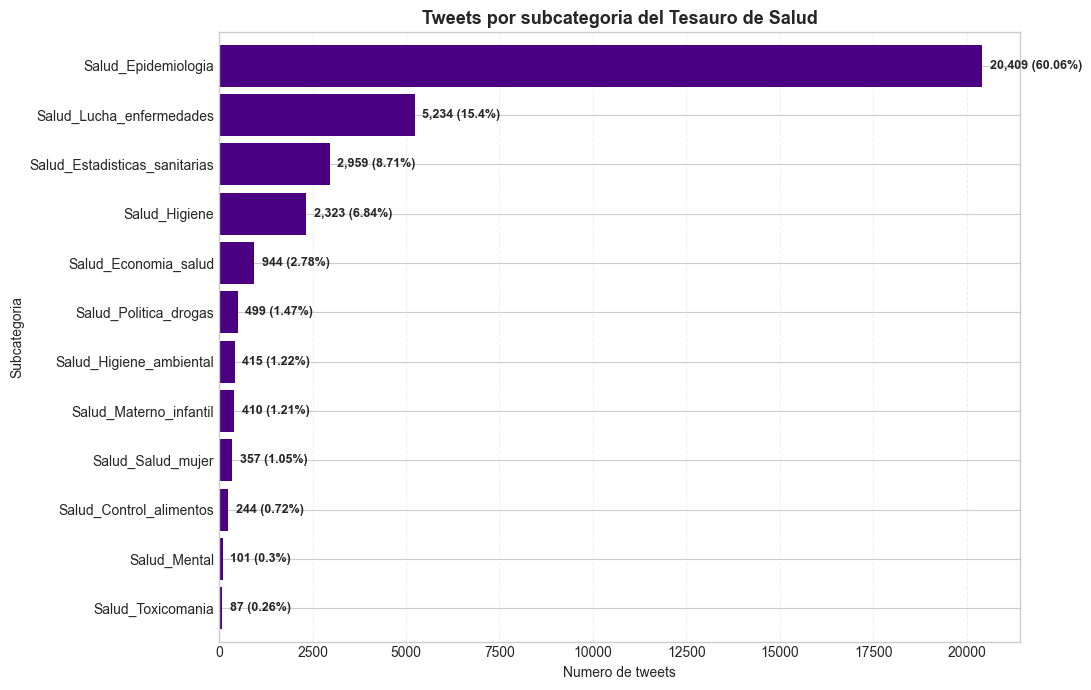

[GUARDADO] fig_distribucion_subcategorias.png


In [4]:
# ============================================================
# CELL 3 — DISTRIBUCION POR SUBCATEGORIA
# Equivalente a celdas 28-31 del paper
# ============================================================

# Conteos y porcentajes
conteos     = tweets_salud['categoria_detectada'].value_counts()
total_salud = conteos.sum()
porcentajes = (conteos / total_salud * 100).round(2)

tabla_subcats = pd.DataFrame({
    'Subcategoria' : conteos.index,
    'N_tweets'     : conteos.values,
    'Porcentaje'   : porcentajes.values,
}).sort_values('N_tweets', ascending=False)

print(tabla_subcats.to_string(index=False))

# Grafica barras horizontales
conteos_ord = conteos.sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(11, 7))
conteos_ord.plot.barh(ax=ax, color='indigo', width=0.85)
for i, (v, pct) in enumerate(zip(
    conteos_ord.values,
    porcentajes[conteos_ord.index].values
)):
    ax.text(v + max(conteos)*0.01, i,
            f'{v:,} ({pct}%)', va='center', fontsize=9, fontweight='bold')
ax.set_title('Tweets por subcategoria del Tesauro de Salud', fontsize=13, fontweight='bold')
ax.set_xlabel('Numero de tweets')
ax.set_ylabel('Subcategoria')
ax.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_distribucion_subcategorias.png', dpi=300)
plt.show()
print('[GUARDADO] fig_distribucion_subcategorias.png')


## 4 · Distribución temporal
Equivalente a las celdas 20-21 del paper: porcentaje mensual de tweets  
con mención de salud sobre el total del corpus.


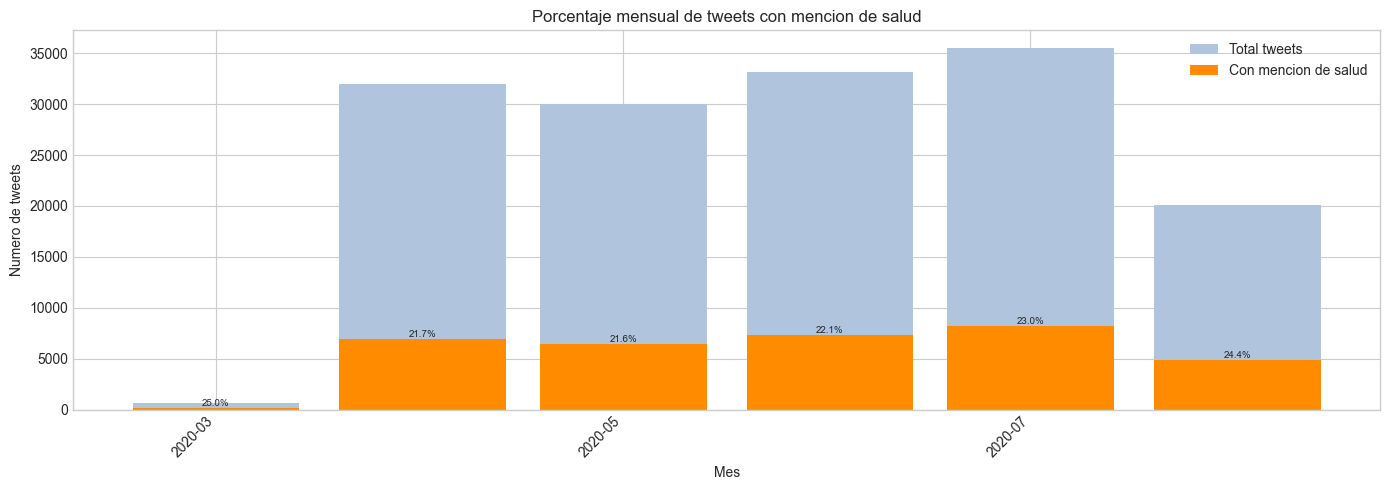

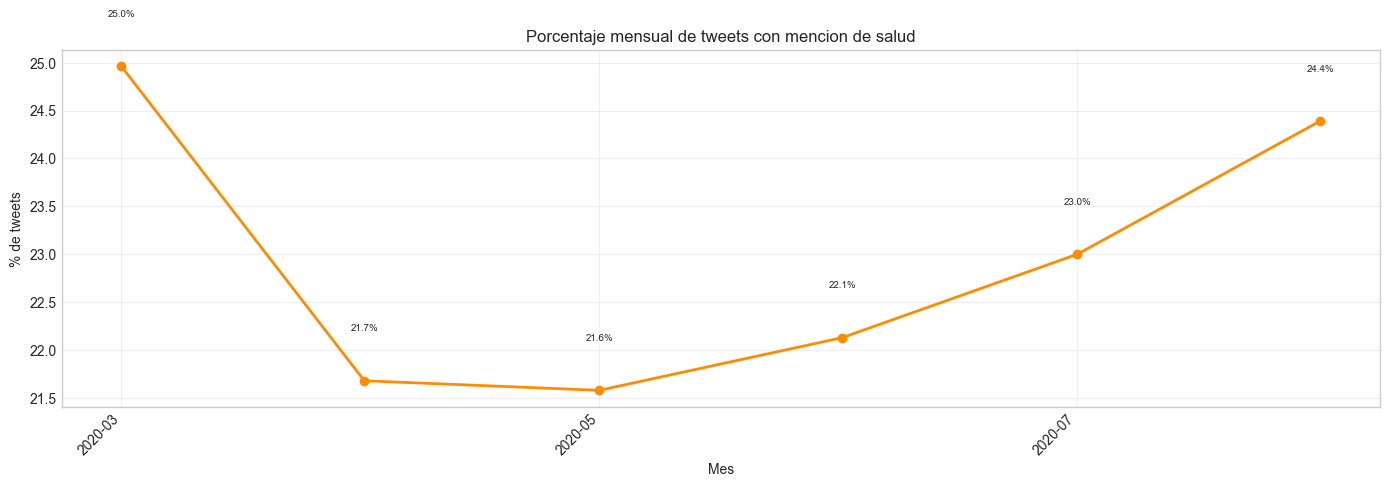

[GUARDADO] figuras temporales


,total_tweets,tweets_salud,porcentaje
AnoMes,,,
2020-03-01,593,148,24.96
2020-04-01,32000,6937,21.68
2020-05-01,30048,6484,21.58
2020-06-01,33193,7346,22.13
2020-07-01,35469,8159,23.00
2020-08-01,20121,4908,24.39


In [5]:
# ============================================================
# CELL 4 — DISTRIBUCION TEMPORAL
# Equivalente a celdas 20-21 del paper
# ============================================================

corpus['AnoMes']       = corpus[COL_FECHA].dt.to_period('M')
tweets_salud['AnoMes'] = tweets_salud[COL_FECHA].dt.to_period('M')

totales   = corpus.groupby('AnoMes')['id_doc'].nunique()
con_salud = tweets_salud.groupby('AnoMes')['id_doc'].nunique()

mensual = pd.DataFrame({
    'total_tweets' : totales,
    'tweets_salud' : con_salud,
}).fillna(0)
mensual['porcentaje'] = (mensual['tweets_salud'] / mensual['total_tweets'] * 100).round(2)
mensual.index = mensual.index.to_timestamp()

# -- Grafica 1: barras apiladas --
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(mensual.index, mensual['total_tweets'],
       color='lightsteelblue', label='Total tweets', width=25)
ax.bar(mensual.index, mensual['tweets_salud'],
       color='darkorange', label='Con mencion de salud', width=25)
for x, y_s, pct in zip(mensual.index, mensual['tweets_salud'], mensual['porcentaje']):
    if y_s > 0:
        ax.text(x, y_s + 2, f'{pct:.1f}%', ha='center', va='bottom', fontsize=7)
ax.set_title('Porcentaje mensual de tweets con mencion de salud')
ax.set_ylabel('Numero de tweets')
ax.set_xlabel('Mes')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_porcentaje_mensual_salud_barras.png', dpi=300)
plt.show()

# -- Grafica 2: linea de porcentaje --
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(mensual.index, mensual['porcentaje'],
        marker='o', linestyle='-', color='darkorange', linewidth=2)
for x, y in zip(mensual.index, mensual['porcentaje']):
    if not np.isnan(y):
        ax.text(x, y + 0.5, f'{y:.1f}%', ha='center', va='bottom', fontsize=7)
ax.set_title('Porcentaje mensual de tweets con mencion de salud')
ax.set_ylabel('% de tweets')
ax.set_xlabel('Mes')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45, ha='right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_porcentaje_mensual_salud_linea.png', dpi=300)
plt.show()
print('[GUARDADO] figuras temporales')
mensual.tail(10)


## 5 · Autores con más tweets de salud
Equivalente a las celdas 22-25 del paper, con gráfico comparativo  
total tweets vs. tweets con mención de salud.


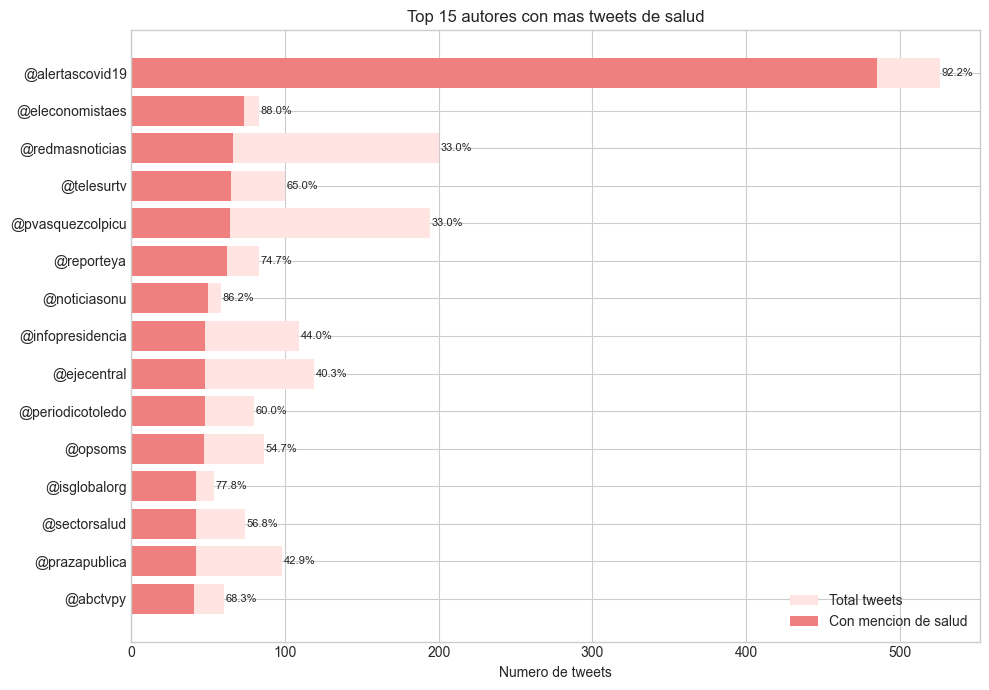

[GUARDADO] fig_autores_salud.png


,Author_Normalized,n_tweets_salud,n_tweets_total,pct_salud
0,@alertascovid19,485,526,92.2
1,@eleconomistaes,73,83,88.0
2,@redmasnoticias,66,200,33.0
3,@telesurtv,65,100,65.0
4,@pvasquezcolpicu,64,194,33.0
5,@reporteya,62,83,74.7
6,@noticiasonu,50,58,86.2
7,@periodicotoledo,48,80,60.0
8,@ejecentral,48,119,40.3
9,@infopresidencia,48,109,44.0


In [6]:
# ============================================================
# CELL 5 — TOP AUTORES
# Equivalente a celdas 22-25 del paper
# ============================================================

autores_salud = (
    tweets_salud.groupby(COL_AUTOR)['id_doc']
    .nunique().reset_index(name='n_tweets_salud')
    .sort_values('n_tweets_salud', ascending=False)
)
autores_total = (
    corpus.groupby(COL_AUTOR)['id_doc']
    .nunique().reset_index(name='n_tweets_total')
)
autores_merge = autores_salud.merge(autores_total, on=COL_AUTOR, how='left')
autores_merge['pct_salud'] = (
    autores_merge['n_tweets_salud'] / autores_merge['n_tweets_total'] * 100
).round(1)

top_autores = autores_merge.head(15).sort_values('n_tweets_salud', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_autores[COL_AUTOR], top_autores['n_tweets_total'],
        color='mistyrose', label='Total tweets')
ax.barh(top_autores[COL_AUTOR], top_autores['n_tweets_salud'],
        color='lightcoral', label='Con mencion de salud')
for i, (n, t, p) in enumerate(zip(
    top_autores['n_tweets_salud'],
    top_autores['n_tweets_total'],
    top_autores['pct_salud']
)):
    ax.text(t + 1, i, f'{p:.1f}%', va='center', fontsize=8)
ax.set_title('Top 15 autores con mas tweets de salud')
ax.set_xlabel('Numero de tweets')
ax.legend()
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_autores_salud.png', dpi=300)
plt.show()
print('[GUARDADO] fig_autores_salud.png')
autores_merge.head(15)


## 6 · Distribución por tipo de cuenta
Equivalente adicional al paper — reemplaza la distribución por diario  
con la distribución por tipo de cuenta (`Entidad`).


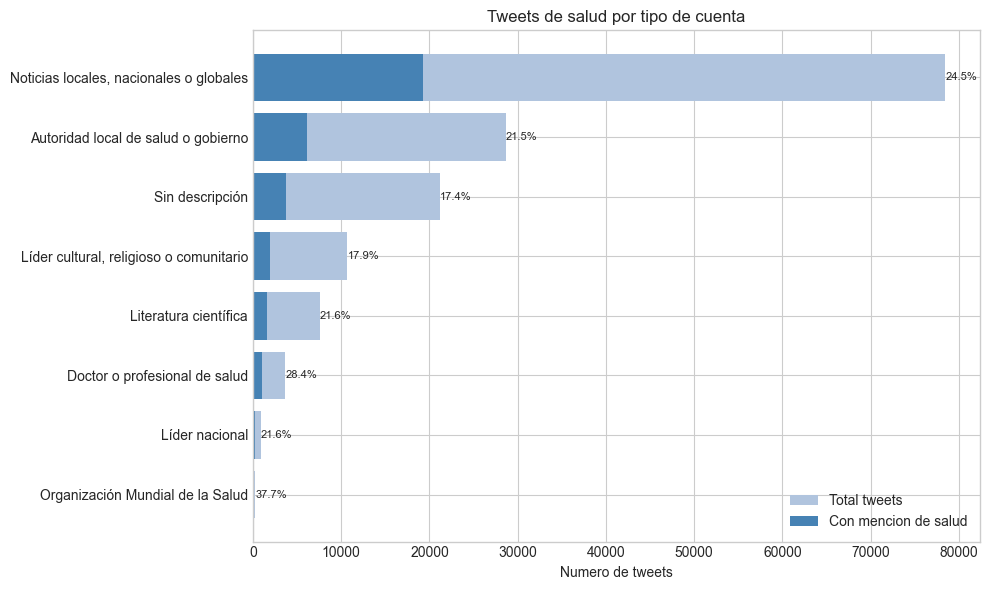

[GUARDADO] fig_entidad_salud.png


,Entidad,n_salud,n_total,pct_salud
5,"Noticias locales, nacionales o globales",19240,78475,24.5
0,Autoridad local de salud o gobierno,6170,28684,21.5
7,Sin descripción,3696,21195,17.4
3,"Líder cultural, religioso o comunitario",1911,10705,17.9
2,Literatura científica,1635,7554,21.6
1,Doctor o profesional de salud,1043,3677,28.4
4,Líder nacional,189,874,21.6
6,Organización Mundial de la Salud,98,260,37.7


In [7]:
# ============================================================
# CELL 6 — POR TIPO DE CUENTA (Entidad)
# Adicional al paper: reemplaza distribucion por diario
# ============================================================

entidad_salud = (
    tweets_salud.groupby(COL_ENTIDAD)['id_doc']
    .nunique().reset_index(name='n_salud')
)
entidad_total = (
    corpus.groupby(COL_ENTIDAD)['id_doc']
    .nunique().reset_index(name='n_total')
)
entidad_merge = entidad_salud.merge(entidad_total, on=COL_ENTIDAD, how='left')
entidad_merge['pct_salud'] = (
    entidad_merge['n_salud'] / entidad_merge['n_total'] * 100
).round(1)
entidad_merge = entidad_merge.sort_values('n_salud', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
top_ent = entidad_merge.head(12).sort_values('n_salud', ascending=True)
ax.barh(top_ent[COL_ENTIDAD], top_ent['n_total'],
        color='lightsteelblue', label='Total tweets')
ax.barh(top_ent[COL_ENTIDAD], top_ent['n_salud'],
        color='steelblue', label='Con mencion de salud')
for i, (n, t, p) in enumerate(zip(
    top_ent['n_salud'], top_ent['n_total'], top_ent['pct_salud']
)):
    ax.text(t + 1, i, f'{p:.1f}%', va='center', fontsize=8)
ax.set_title('Tweets de salud por tipo de cuenta')
ax.set_xlabel('Numero de tweets')
ax.legend()
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_entidad_salud.png', dpi=300)
plt.show()
print('[GUARDADO] fig_entidad_salud.png')
entidad_merge


## 7 · Nubes de palabras comparativas
Equivalente al notebook `6_1_nubes_palabras_comparativas.ipynb`:  
corpus general vs. subcorpus de salud, con los mismos parámetros del paper.


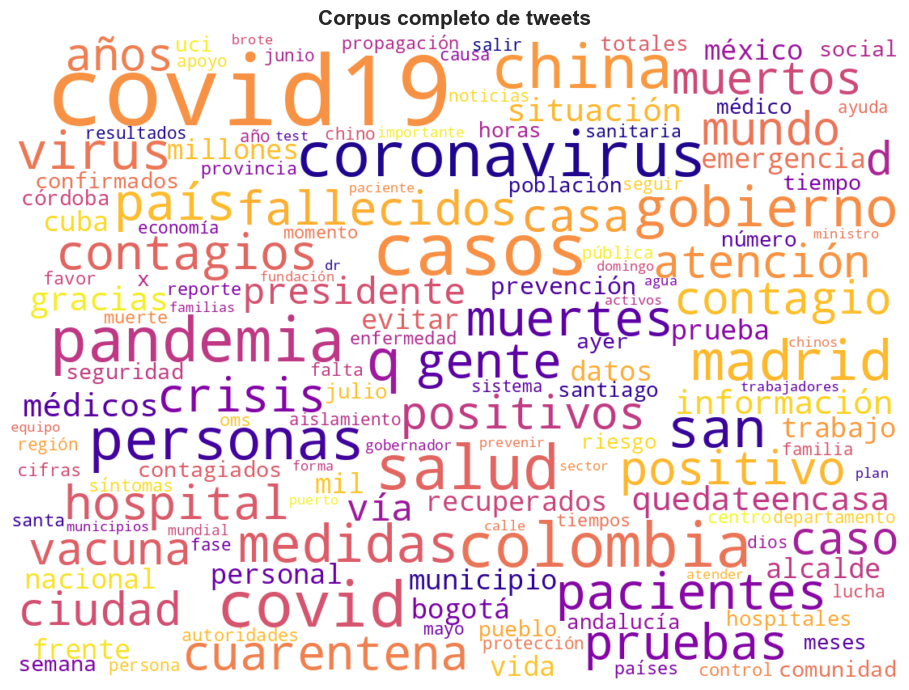

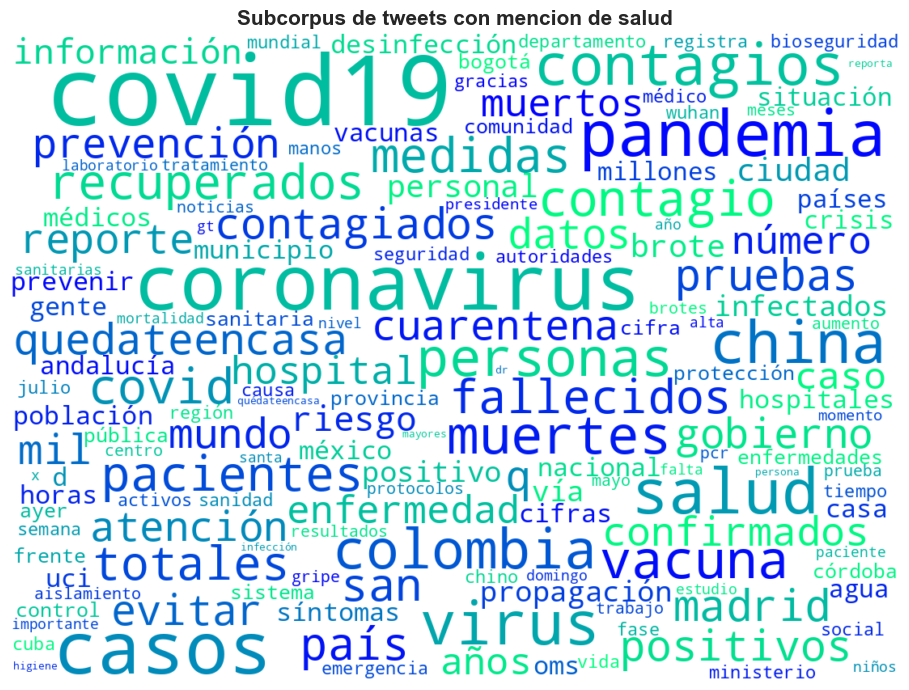

[GUARDADO] nube_corpus_general.png
[GUARDADO] nube_subcorpus_salud.png


In [8]:
# ============================================================
# CELL 7 — NUBES COMPARATIVAS
# Equivalente a 6_1_nubes_palabras_comparativas.ipynb
# ============================================================

subprocess.run([sys.executable, '-m', 'spacy', 'download', 'es_core_news_sm'],
               capture_output=True)
nlp = spacy.load('es_core_news_sm')
STOP_WORDS = nlp.Defaults.stop_words

WC_PARAMS_BASE = dict(
    width=1100, height=800,
    background_color='white',
    max_words=150,
    stopwords=STOP_WORDS,
    prefer_horizontal=1.0,
    relative_scaling=0.3,
    max_font_size=120,
    min_font_size=8,
    collocations=False,
    random_state=42,
    normalize_plurals=False,
)

# -- Nube 1: corpus completo (colormap plasma, igual que el paper) --
texto_general = ' '.join(corpus['Texto_limpio'].dropna()).lower()
wc_general = WordCloud(**WC_PARAMS_BASE, colormap='plasma').generate(texto_general)

fig, ax = plt.subplots(figsize=(12, 7))
ax.imshow(wc_general, interpolation='bilinear')
ax.axis('off')
ax.set_title('Corpus completo de tweets', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'nube_corpus_general.png', dpi=300)
plt.show()

# -- Nube 2: subcorpus de salud (colormap winter, igual que el paper) --
texto_salud = ' '.join(tweets_salud['Texto_limpio'].dropna()).lower()
wc_salud = WordCloud(**WC_PARAMS_BASE, colormap='winter').generate(texto_salud)

fig, ax = plt.subplots(figsize=(12, 7))
ax.imshow(wc_salud, interpolation='bilinear')
ax.axis('off')
ax.set_title('Subcorpus de tweets con mencion de salud', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'nube_subcorpus_salud.png', dpi=300)
plt.show()

print('[GUARDADO] nube_corpus_general.png')
print('[GUARDADO] nube_subcorpus_salud.png')


## 8 · Tabla de frecuencias comparativas
Equivalente a las celdas 36-37 del paper: palabras más frecuentes en el  
subcorpus de salud comparadas con el corpus completo, con proporción.


In [9]:
# ============================================================
# CELL 8 — FRECUENCIAS COMPARATIVAS
# Equivalente a celdas 36-37 del paper
# ============================================================

def obtener_frecuencias(textos, stopwords, n=None):
    """
    Replica de utils.obtener_frecuencias() del paper.
    Extrae tokens, elimina stopwords y devuelve frecuencias.
    """
    texto_unido = ' '.join(map(str, textos)).lower()
    tokens = re.findall(r'\b[a-zaeiounyus]+\b', texto_unido)
    tokens = [t for t in tokens if t not in stopwords and len(t) > 2]
    return Counter(tokens).most_common(n)


df_corpus_freq = pd.DataFrame(
    obtener_frecuencias(corpus['Texto_limpio'], STOP_WORDS),
    columns=['palabra', 'frecuencia_corpus']
)
df_salud_freq = pd.DataFrame(
    obtener_frecuencias(tweets_salud['Texto_limpio'], STOP_WORDS),
    columns=['palabra', 'frecuencia_salud']
)

tabla_freq = (
    df_corpus_freq.merge(df_salud_freq, on='palabra', how='outer')
    .fillna(0)
)
tabla_freq[['frecuencia_corpus', 'frecuencia_salud']] = (
    tabla_freq[['frecuencia_corpus', 'frecuencia_salud']].astype(int)
)
tabla_freq['proporcion_salud'] = tabla_freq.apply(
    lambda r: r['frecuencia_salud'] / r['frecuencia_corpus']
    if r['frecuencia_corpus'] > 0 else 0, axis=1
).round(3)

tabla_top = tabla_freq.sort_values('frecuencia_salud', ascending=False).head(30)
print('Top 20 palabras mas frecuentes en tweets de salud:')
print(tabla_top.head(20).to_string(index=False))
tabla_top.head(20)


Top 20 palabras mas frecuentes en tweets de salud:
    palabra  frecuencia_corpus  frecuencia_salud  proporcion_salud
coronavirus              10907              9476             0.869
      casos              19687              7753             0.394
   pandemia              10253              4581             0.447
      salud              10454              4167             0.399
      virus               5596              3645             0.651
      china               9886              3506             0.355
  contagios               4671              3195             0.684
   colombia              10311              2807             0.272
    muertes               4883              2564             0.525
   personas               7876              2554             0.324
     vacuna               3550              2454             0.691
   contagio               3422              1955             0.571
  pacientes               5143              1852             0.360
      covid

,palabra,frecuencia_corpus,frecuencia_salud,proporcion_salud
24557,coronavirus,10907,9476,0.869
16315,casos,19687,7753,0.394
72443,pandemia,10253,4581,0.447
88089,salud,10454,4167,0.399
102746,virus,5596,3645,0.651
18316,china,9886,3506,0.355
23393,contagios,4671,3195,0.684
20602,colombia,10311,2807,0.272
66608,muertes,4883,2564,0.525
75009,personas,7876,2554,0.324


## 9 · Palabras más asociadas al subcorpus de salud
Equivalente a la celda 46 del paper: filtramos por `proporcion_salud > umbral`  
para encontrar términos que aparecen proporcionalmente más en salud que en el corpus general.


In [10]:
# ============================================================
# CELL 9 — PALABRAS MAS ASOCIADAS A SALUD
# Equivalente a: tabla_top[tabla_top['proporcion_columnas'] > 0.6]
# ============================================================

# Proporcion base = % de tweets que son de salud
prop_base = len(tweets_salud) / len(corpus)
print(f'Proporcion base (tweets salud / total): {prop_base:.3f}')

# Palabras con proporcion significativamente mayor a la base
umbral_prop = prop_base * 1.5   # al menos 50% mas frecuente en salud
palabras_salud = (
    tabla_freq[
        (tabla_freq['proporcion_salud'] > umbral_prop) &
        (tabla_freq['frecuencia_salud'] >= 10)  # con frecuencia minima
    ]
    .sort_values('frecuencia_salud', ascending=False)
    .head(30)
)
print(f'\nPalabras mas asociadas al subcorpus de salud '
      f'(proporcion > {umbral_prop:.2f}):')
print(palabras_salud.to_string(index=False))


Proporcion base (tweets salud / total): 0.224

Palabras mas asociadas al subcorpus de salud (proporcion > 0.34):
      palabra  frecuencia_corpus  frecuencia_salud  proporcion_salud
  coronavirus              10907              9476             0.869
        casos              19687              7753             0.394
     pandemia              10253              4581             0.447
        salud              10454              4167             0.399
        virus               5596              3645             0.651
        china               9886              3506             0.355
    contagios               4671              3195             0.684
      muertes               4883              2564             0.525
       vacuna               3550              2454             0.691
     contagio               3422              1955             0.571
    pacientes               5143              1852             0.360
  recuperados               2837              1752         

## 10 · Guardar tablas

In [11]:
# ============================================================
# CELL 10 — GUARDAR TABLAS
# ============================================================

ruta_excel = DATA_PROCESSED / 'tabla_frecuencias_salud.xlsx'

with pd.ExcelWriter(ruta_excel, engine='openpyxl') as writer:
    tabla_subcats.to_excel(writer,    sheet_name='Subcategorias',      index=False)
    mensual.reset_index().to_excel(writer, sheet_name='Temporal',      index=False)
    autores_merge.to_excel(writer,    sheet_name='Top_autores',        index=False)
    entidad_merge.to_excel(writer,    sheet_name='Por_tipo_cuenta',    index=False)
    tabla_top.to_excel(writer,        sheet_name='Frecuencias_top30',  index=False)
    palabras_salud.to_excel(writer,   sheet_name='Palabras_salud',     index=False)

print(f'[GUARDADO] tabla_frecuencias_salud.xlsx')
print()
print('Notebook 05 completado.')
print('Siguiente -> 06_NER.ipynb')


[GUARDADO] tabla_frecuencias_salud.xlsx

Notebook 05 completado.
Siguiente -> 06_NER.ipynb
